In [2]:
# ================================================
# IPL Business Intelligence & Forecasting Project
# Notebook 5: Trend Analysis & Forecasting
# Author: Bhoomi Thakur
# Date: April 2026
# ================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load cleaned IPL dataset
ipl = pd.read_csv('E:\\ipl_dataset1\\ipl_clean.csv',
                   low_memory=False)

# Fix season format to single year
ipl['season'] = ipl['season'].astype(str).str[:4].astype(int)

# Remove incomplete 2026 season
ipl = ipl[ipl['season'] != 2026]

# Create match level dataframe (one row per match)
matches = ipl.drop_duplicates(subset='match_id')

print("Ready for forecasting!")
print("Seasons:", sorted(ipl['season'].unique()))

Ready for forecasting!
Seasons: [np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [3]:
# Calculate runs per match per season
season_runs = ipl.groupby('season').agg(
    total_runs=('runs_batter', 'sum'),
    total_matches=('match_id', 'nunique')
).reset_index()

season_runs['runs_per_match'] = (
    season_runs['total_runs'] / 
    season_runs['total_matches']
).round(2)

print(season_runs)

    season  total_runs  total_matches  runs_per_match
0     2007       16809             58          289.81
1     2009       33130            117          283.16
2     2011       19928             73          272.99
3     2012       21323             74          288.15
4     2013       21487             76          282.72
5     2014       17943             60          299.05
6     2015       17427             59          295.37
7     2016       17962             60          299.37
8     2017       17920             59          303.73
9     2018       19098             60          318.30
10    2019       18607             60          310.12
11    2020       18566             60          309.43
12    2021       17727             60          295.45
13    2022       23052             74          311.51
14    2023       24428             74          330.11
15    2024       24657             71          347.28
16    2025       25309             74          342.01


In [4]:
# Fit trendline using numpy polyfit
x = season_runs['season'].values
y = season_runs['runs_per_match'].values

# Fit a straight line (degree 1)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Predict next 3 seasons
future_seasons = [2026, 2027, 2028]
predictions = p(future_seasons)

print("\nForecasted Runs Per Match:")
for season, pred in zip(future_seasons, predictions):
    print(f"{season}: {pred:.2f}")


Forecasted Runs Per Match:
2026: 334.80
2027: 338.08
2028: 341.37


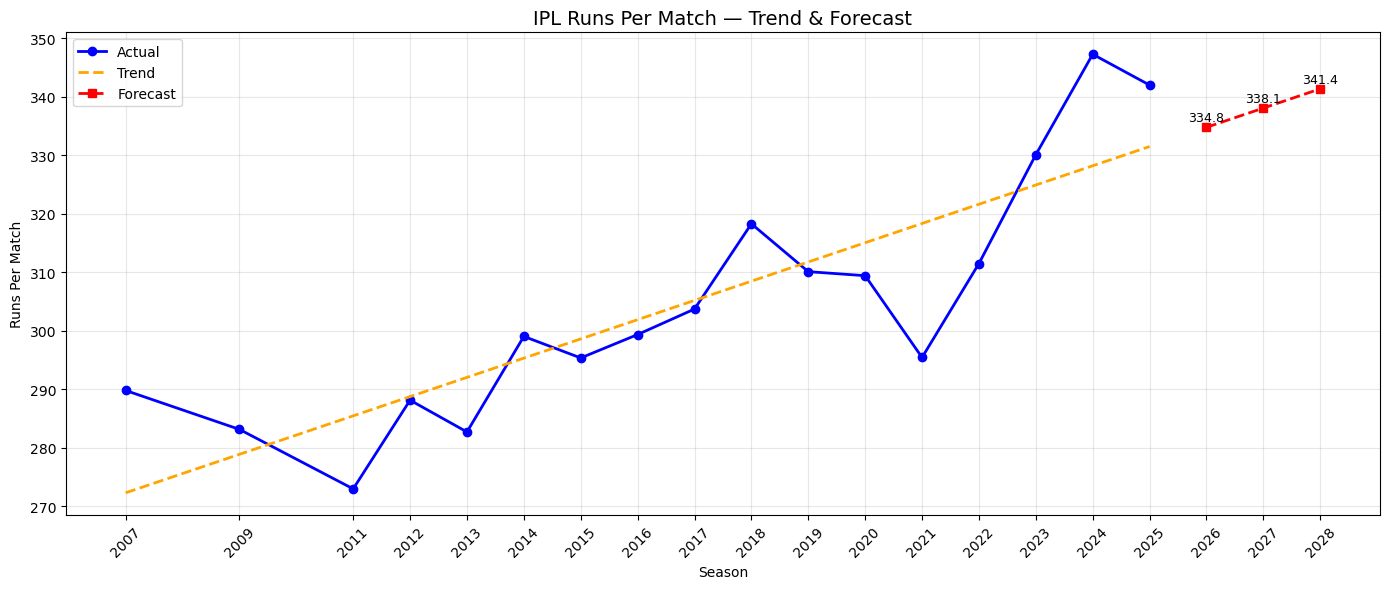

In [5]:
plt.figure(figsize=(14, 6))

# Actual data
plt.plot(x, y, marker='o', color='blue', 
         linewidth=2, label='Actual')

# Trendline on historical data
plt.plot(x, p(x), color='orange', linestyle='--',
         linewidth=2, label='Trend')

# Future predictions
plt.plot(future_seasons, predictions, marker='s',
         color='red', linestyle='--',
         linewidth=2, label='Forecast')

# Add value labels on predictions
for season, pred in zip(future_seasons, predictions):
    plt.text(season, pred + 1, f'{pred:.1f}', 
             ha='center', fontsize=9)

plt.title('IPL Runs Per Match — Trend & Forecast', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Runs Per Match')
plt.legend()
plt.grid(True, alpha=0.3)

seasons_all = list(x) + future_seasons
plt.xticks(seasons_all, rotation=45)

plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\runs_forecast.png', 
            dpi=150)
plt.show()

In [8]:
# Win rate per season for top 3 teams
top3 = ['Mumbai Indians', 'Chennai Super Kings', 
        'Kolkata Knight Riders']

# Total matches per team per season
total_season = pd.concat([
    matches[['season', 'batting_team']].rename(
        columns={'batting_team': 'team'}),
    matches[['season', 'bowling_team']].rename(
        columns={'bowling_team': 'team'})
]).groupby(['season', 'team']).size().reset_index(name='total')

# Wins per team per season
wins_season = matches[
    matches['match_won_by'] != 'Unknown'
].groupby(['season', 'match_won_by']).size()\
 .reset_index(name='wins')

# Merge
season_wr = wins_season.merge(
    total_season,
    left_on=['season', 'match_won_by'],
    right_on=['season', 'team']
)
season_wr['win_rate'] = (
    season_wr['wins'] / season_wr['total'] * 100
).round(2)

# Filter top 3
season_wr = season_wr[season_wr['team'].isin(top3)]
print(season_wr.head())

   season           match_won_by  wins                   team  total  win_rate
0    2007    Chennai Super Kings     9    Chennai Super Kings     16     56.25
1    2007  Kolkata Knight Riders     6  Kolkata Knight Riders     13     46.15
2    2007         Mumbai Indians     7         Mumbai Indians     14     50.00
4    2009    Chennai Super Kings    17    Chennai Super Kings     30     56.67
5    2009  Kolkata Knight Riders    10  Kolkata Knight Riders     27     37.04


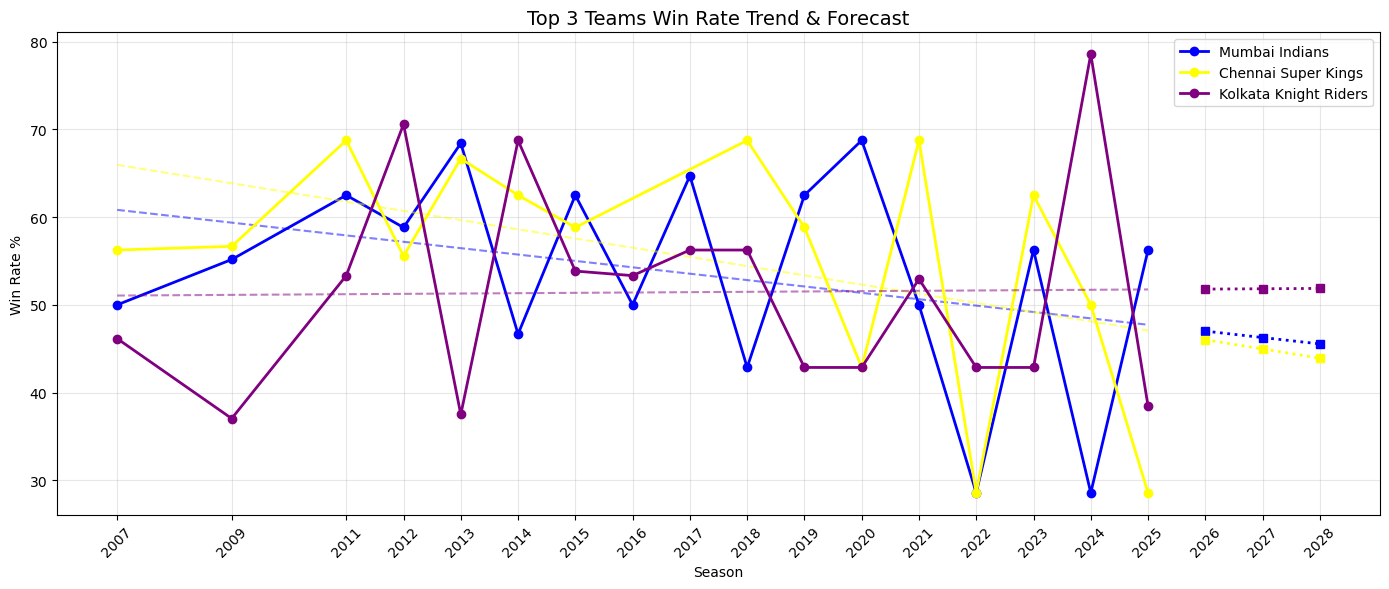

In [9]:
plt.figure(figsize=(14, 6))

colors = ['blue', 'yellow', 'purple']

for i, team in enumerate(top3):
    team_data = season_wr[season_wr['team'] == team]
    
    x = team_data['season'].values
    y = team_data['win_rate'].values
    
    # Plot actual data
    plt.plot(x, y, marker='o', color=colors[i], 
             linewidth=2, label=team)
    
    # Fit trendline
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    
    # Plot trendline
    plt.plot(x, p(x), color=colors[i], 
             linestyle='--', alpha=0.5)
    
    # Forecast 2026-2028
    future = [2026, 2027, 2028]
    plt.plot(future, p(future), marker='s',
             color=colors[i], linestyle='dotted',
             linewidth=2)

plt.title('Top 3 Teams Win Rate Trend & Forecast', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Win Rate %')
plt.legend()
plt.grid(True, alpha=0.3)

all_seasons = list(season_wr['season'].unique()) + [2026, 2027, 2028]
plt.xticks(sorted(all_seasons), rotation=45)

plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\team_forecast.png', dpi=150)
plt.show()